# Making the dataset and training the model

This file contains the code to make the dataset from depth tensor and the embeddings retrieved from the same tensors. But also one thing to keep track is 
error value of -1 for places where no depth values could be retriebed. They need to be filtered out and left out of the final training data. 

In [1]:
import argparse
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

In [2]:
from utils import getDevice

Using device: xpu :3
Setting seed to 42:3


In [3]:
class EmbedDepthDataset(Dataset):
    """
    This class matched the YOLO embeddings from a file to depth retrieved
    for the same images and creates a dataset from them, that can be used to 
    train the final model.

    Args:
        embed_path: path to .pt embeddings (N,256)
        depths_path: path to .pt (N,)
    """

    def __init__(self, embed_path: str, depths_path: str):
        #opening the files
        embeds = torch.load(embed_path, weights_only=True).float()
        depths = torch.load(depths_path, weights_only=True).float()

        #filtering depths to only allow valid ones
        print(f"Removing {(depths==-1).sum()} invalid depths")
        mask = depths != -1
        embeds_masked = embeds[mask]
        depths_masked = depths[mask]   

        #saving results
        self.depths = depths_masked
        self.embeddings = embeds_masked

        assert len(self.embeddings)==len(self.depths), (
            f"The embeddings array is not the same length as the depths"
            f"EMBEDDINGS: {len(self.embeddings)}\nDEPTHS: {len(self.depths)}"
        )

    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.depths[idx]

In [4]:
class DistanceRegressor(nn.Module):
    """
    Model to predict based on YOLO embeddings the distance to a car. It takes in (256) embedding and 
    outputs a single distance value in meters.

    Architecture is similar to the paper:
    1. Linear(256,128) + ReLU
    2. Linear(128,64) + ReLU
    3. Linear(64,1) + Softplus (to ensure positive output)
    """

    def __init__(self, input_size: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(512, 1),
            nn.Softplus()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [5]:
def run_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, loss_fn, device, train:bool):
    """
    Runs an epoch. Can be used for training and evaluation of the model.

    Args:
        model: the model to train/evaluate
        loader: dataloader for the dataset
        optimizer: optimizer to use for training (ignored if train=False)
        error_fn: loss function to use for error calculation
        device: device to run on (cpu or cuda)
        train: whether to run in training mode (True) or evaluation mode (False)
    """
    model.train() if train else model.eval()
    model_loss = 0

    #set modes according to train state
    with torch.set_grad_enabled(train):
        for embeds, depths in loader:
            #move inputs and target values to correct device
            embeds, depths = embeds.to(device), depths.to(device)

            #values are predicted and error calculation
            preds = model(embeds).squeeze()



            preds = preds.cpu()
            depths = depths.cpu()
            loss = loss_fn(preds, depths)
            model_loss += loss.item()

            #training step perforned here 
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
    return model_loss / len(loader)

def train_model(
        model: nn.Module, 
        dataset: Dataset, 
        optimizer: torch.optim.Optimizer, 
        loss_fn,
        device: torch.device, 
        scheduler=None,
        epochs: int = 20, 
        batch_size: int = 64
    ):
    """
    Trains the model on the given dataset.

    Args:
        model: the model for training
        dataset: embeddings-depths pairs
        optimizer:optimizer to trains
        loss_fn: loss function to track progress
        device: string where to run the model
        epochs: number of epochs to run
        batch_size:
        learning_rate:
    """
    #we accumulate the losses 
    train_losses = np.array([])
    val_losses = np.array([])
    model.to(device)

    #split dataset into train and validation sets
    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    #create dataloaders for both sets
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    #training loop
    for epoch in range(epochs):
        train_loss = run_epoch(model, train_loader, optimizer, loss_fn, device, train=True)
        val_loss = run_epoch(model, val_loader, optimizer, loss_fn, device, train=False)
        #results are saved
        train_losses = np.append(train_losses, train_loss)
        val_losses = np.append(val_losses, val_loss)

        #scheduler decreases the learning rate if needed
        if scheduler is not None:
            scheduler.step()

        #progress printed
        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

## Training the models

This sections sets the hyperparametes of the models and the training aspects like th optimizer and the number of epochs. Most of the actual logic is maneged by the functions declared above as it is very much consistent and doesn't change significantly. 

In [ ]:
USE_OG_BOXES=True

if USE_OG_BOXES:
    EMBED_YOLO_PATH = "../data/embeds_yolo_og_boxes.pt"
    EMBEDS_DINO_PATH = "../data/embeds_dino_og_boxes.pt"
    DEPTHS_PATH = "../data/true_depth.pt"
    IMG_SUFFIX = "og_boxes"
else:
    EMBED_YOLO_PATH = "../data/embeds_yolo.pt"
    EMBEDS_DINO_PATH = "../data/embeds_dino.pt"
    DEPTHS_PATH = "../data/ransac_depth.pt"
    ING_SUFFIX = "yolo_boxes"

dataset_yolo = EmbedDepthDataset(EMBED_YOLO_PATH, DEPTHS_PATH)
dataset_dino = EmbedDepthDataset(EMBEDS_DINO_PATH, DEPTHS_PATH)

Removing 0 invalid depths
Removing 0 invalid depths


### YOLO based approach

In [7]:


# Create the loss function,  model
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss
model_yolo = DistanceRegressor()

# Create the optimizer and scheduler
optimizer = torch.optim.Adam(model_yolo.parameters(), lr=0.001, eps=1.0)
scheduler = StepLR(optimizer, step_size=50, gamma=0.75)

epochs = 300

In [8]:
train_losses_yolo, val_losses_yolo = train_model(
    model=model_yolo,
    dataset=dataset_yolo,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=getDevice(),
    epochs=epochs,
    scheduler=scheduler
)

Epoch 0/300 - Train Loss: 19.3677 - Val Loss: 13.1282
Epoch 10/300 - Train Loss: 3.6224 - Val Loss: 4.6179
Epoch 20/300 - Train Loss: 3.2678 - Val Loss: 2.8270
Epoch 30/300 - Train Loss: 3.1139 - Val Loss: 2.6370
Epoch 40/300 - Train Loss: 2.9341 - Val Loss: 2.8935
Epoch 50/300 - Train Loss: 2.7929 - Val Loss: 2.7273
Epoch 60/300 - Train Loss: 2.7908 - Val Loss: 2.4566
Epoch 70/300 - Train Loss: 2.7479 - Val Loss: 2.3289
Epoch 80/300 - Train Loss: 2.6408 - Val Loss: 2.3350
Epoch 90/300 - Train Loss: 2.6237 - Val Loss: 2.4789
Epoch 100/300 - Train Loss: 2.5688 - Val Loss: 2.4117
Epoch 110/300 - Train Loss: 2.5170 - Val Loss: 2.2505
Epoch 120/300 - Train Loss: 2.4598 - Val Loss: 2.3755
Epoch 130/300 - Train Loss: 2.4639 - Val Loss: 2.3938
Epoch 140/300 - Train Loss: 2.4310 - Val Loss: 2.2719
Epoch 150/300 - Train Loss: 2.4128 - Val Loss: 2.2474
Epoch 160/300 - Train Loss: 2.3054 - Val Loss: 2.2523
Epoch 170/300 - Train Loss: 2.4005 - Val Loss: 2.2897
Epoch 180/300 - Train Loss: 2.3626 - 

### DINOv3 bases approach

In [9]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss
model_dino = DistanceRegressor(input_size=384)

# Create the optimizer
optimizer = torch.optim.Adam(model_dino.parameters(), lr=0.001, eps=1.0)
scheduler = StepLR(optimizer, step_size=50, gamma=0.75)

# number of epochs
epochs = 300

# train the model
train_losses_dino, val_losses_dino = train_model(
    model=model_dino,
    dataset=dataset_dino,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    device=getDevice(),
    scheduler=scheduler
)

Epoch 0/300 - Train Loss: 19.0804 - Val Loss: 12.0185
Epoch 10/300 - Train Loss: 2.6222 - Val Loss: 3.4810
Epoch 20/300 - Train Loss: 2.4059 - Val Loss: 2.7034
Epoch 30/300 - Train Loss: 2.3268 - Val Loss: 2.0673
Epoch 40/300 - Train Loss: 2.1799 - Val Loss: 2.6526
Epoch 50/300 - Train Loss: 2.1136 - Val Loss: 2.1067
Epoch 60/300 - Train Loss: 2.0745 - Val Loss: 2.1676
Epoch 70/300 - Train Loss: 2.0259 - Val Loss: 2.1639
Epoch 80/300 - Train Loss: 1.9809 - Val Loss: 2.0755
Epoch 90/300 - Train Loss: 1.9603 - Val Loss: 1.4883
Epoch 100/300 - Train Loss: 1.8822 - Val Loss: 1.9884
Epoch 110/300 - Train Loss: 1.8082 - Val Loss: 1.9667
Epoch 120/300 - Train Loss: 1.8703 - Val Loss: 1.7898
Epoch 130/300 - Train Loss: 1.8086 - Val Loss: 1.8617
Epoch 140/300 - Train Loss: 1.7875 - Val Loss: 1.9895
Epoch 150/300 - Train Loss: 1.7612 - Val Loss: 1.6621
Epoch 160/300 - Train Loss: 1.7571 - Val Loss: 2.1633
Epoch 170/300 - Train Loss: 1.7225 - Val Loss: 1.6189
Epoch 180/300 - Train Loss: 1.7362 - 

## Visualizations

The training produces error rates 1 number per epoch. It is the average accuracy the model at the moment. These graphs are used to plot the results in different ways to see individual model performance as well as compare them to each other. 

General trends as observed is that with the same parameters the DINO based version outperforms the YOLO by about 1m or so yet with both of them having significant error rates of close to 2.5m in the end.

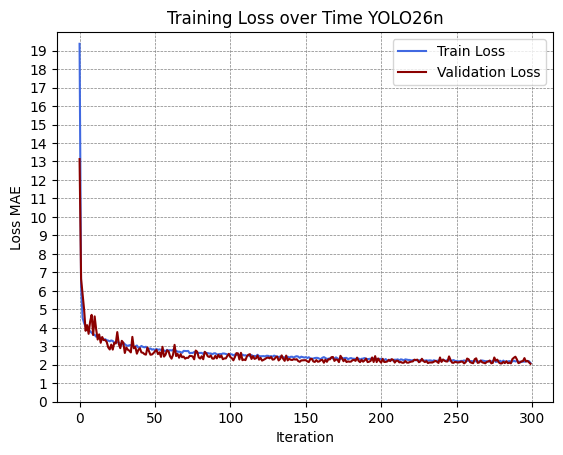

In [10]:
plt.plot(train_losses_yolo, label="Train Loss", color="royalblue")
plt.plot(val_losses_yolo, label="Validation Loss", color="darkred")
plt.xlabel("Iteration")
plt.ylabel("Loss MAE")
plt.ylim(0, 20)
plt.yticks(np.arange(0, 20, 1))
plt.title("Training Loss over Time YOLO26n")
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()    
plt.savefig("../visualizations/loss_plot_yolo_og.png")
plt.show()

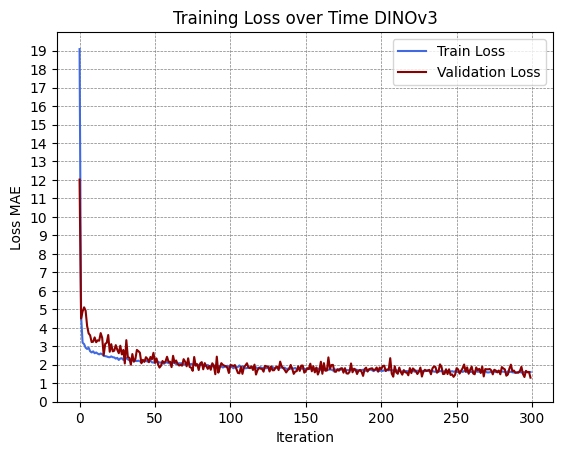

In [11]:
plt.plot(train_losses_dino, label="Train Loss", color="royalblue")
plt.plot(val_losses_dino, label="Validation Loss", color="darkred")
plt.xlabel("Iteration")
plt.ylabel("Loss MAE")
plt.ylim(0, 20)
plt.yticks(np.arange(0, 20, 1))
plt.title("Training Loss over Time DINOv3")
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()    
plt.savefig("../visualizations/loss_plot_dino_og.png")
plt.show()

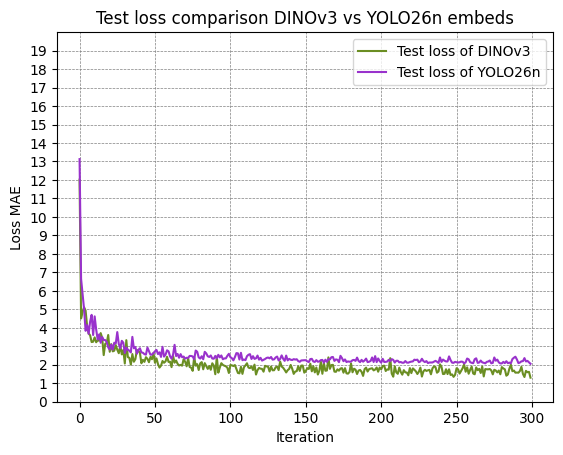

In [12]:
plt.plot(val_losses_dino, label="Test loss of DINOv3", color="olivedrab")
plt.plot(val_losses_yolo, label="Test loss of YOLO26n", color="darkorchid")
plt.xlabel("Iteration")
plt.ylabel("Loss MAE")
plt.ylim(0, 20)
plt.yticks(np.arange(0, 20, 1))
plt.title("Test loss comparison DINOv3 vs YOLO26n embeds")
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()    
plt.savefig("../visualizations/dino_yolo_comparison_test_og.png")
plt.show()

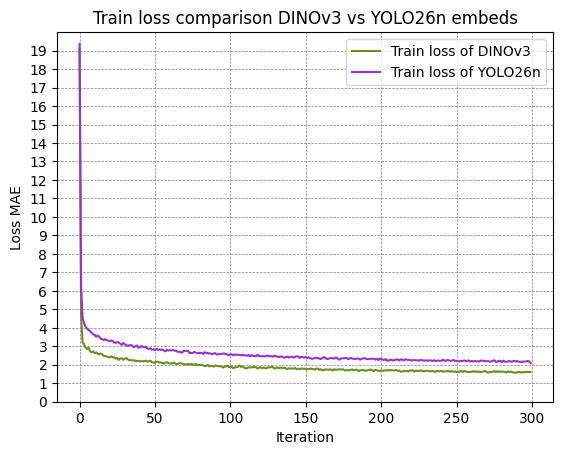

In [13]:
plt.plot(train_losses_dino, label="Train loss of DINOv3", color="olivedrab")
plt.plot(train_losses_yolo, label="Train loss of YOLO26n", color="darkorchid")
plt.xlabel("Iteration")
plt.ylabel("Loss MAE")
plt.ylim(0, 20)
plt.yticks(np.arange(0, 20, 1))
plt.title("Train loss comparison DINOv3 vs YOLO26n embeds")
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.legend()    
plt.savefig("../visualizations/dino_yolo_comparison_train_og.png")
plt.show()

## Comparison of the final models

Here I want to try comparing the final models on the dataset. This borrows the approach I saw in one of the papers, where they plotted the error rates versus the depths where they were predicted.

This can show if the accuracy is consistent across the board or what is more likely certain ranges tend to be more accurate than others.